<div style="
background: linear-gradient(135deg, #fceff9, #e3f2fd);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #dcdcdc;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width : 1800px;
margin : auto;
">

<h1 style="color:#5C6BC0; font-size:40px; margin-bottom:10px;">
🍷 Clasificador de Calidad de Vinos Tintos con KNN
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Predicción Inteligente de Calidad del Vino mediante Machine Learning
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 25px 0;">

<p style="font-size:18px; color:#444;">
📊 <b>Análisis Exploratorio de Datos (EDA)</b><br>
🧪 <b>Análisis de Variables Químicas del Vino</b><br>
🤖 <b>Clasificación Supervisada con K-Nearest Neighbors (KNN)</b><br>
⚙️ <b>Escalado de Variables y Preparación del Dataset</b><br>
🔎 <b>Optimización del Hiperparámetro K</b><br>
📈 <b>Evaluación del Modelo y Comparación de Resultados</b>
</p>

<br>

<p style="font-size:14px; color:#888;">
✨ “La Inteligencia Artificial también puede aprender a elegir un vino digno de sommelier.” ✨
</p>

</div>

<div style="
background: linear-gradient(135deg,#fdfbfb,#e8eaf6);
padding:35px;
border-radius:20px;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width:1200px;
margin:auto;
font-family:Arial;
">

<h2 style="text-align:center;color:#5C6BC0;">
📑 Índice del Proyecto
</h2>

<hr>

<ul style="font-size:18px; line-height:2; list-style:none;">

<li>🔍 <a href="#eda">Análisis Exploratorio de Datos (EDA)</a></li>

<li>🏷️ <a href="#label">Creación de la Variable Label</a></li>

<li>✂️ <a href="#split">División y Preparación de Datos</a></li>

<li>🤖 <a href="#training">Entrenamiento del Modelo KNN</a></li>

<li>📊 <a href="#evaluation">Evaluación del Modelo</a></li>

<li>⚙️ <a href="#optimization">Optimización del Hiperparámetro K</a></li>

<li>🏆 <a href="#bestk">Modelo Óptimo (Best K)</a></li>

<li>🛡️ <a href="#stablek">Modelo Estable</a></li>

<li>🍷 <a href="#prediction">Predicción de Calidad del Vino</a></li>

<li>💬 <a href="#conclusion">Conclusión Final</a></li>

</ul>

</div>

# Clasificador de Vinos con KNN
Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

Utilizaremos el siguiente dataset de vinos tintos extraido de Wine Quality Data Set - UCI

https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv


Descripción de las columnas

Cada fila representa un vino. Las columnas describen su composición química:

fixed acidity, volatile acidity, citric acid

residual sugar, chlorides

free sulfur dioxide, total sulfur dioxide

density, pH, sulphates, alcohol

La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

¡Empecemos! 😎
Carga los datos. Carga el CSV con Pandas y explora su estructura.

Entrena el modelo KNN:

Separa las variables independientes (X) del objetivo (y).

Divide en conjunto de entrenamiento y prueba (80/20).

Escala los datos si es necesario (¡muy recomendable con KNN!).

Entrena el modelo con un valor de k inicial.

Evalúa el rendimiento usando:

accuracy_score

confusion_matrix

classification_report

Optimización de k. Crea un bucle para probar diferentes valores de k (por ejemplo, de 1 a 20).

Guarda los resultados en una lista.

Grafica accuracy vs k para encontrar el mejor valor.

¿Te sientes confiado/a?
Crea una función que reciba valores numéricos y prediga la calidad

predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
>>> "Este vino probablemente sea de calidad media 🍷"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("../data/raw/winequality-red.csv", sep=";")

<a id="eda"></a>
<div style="
background: linear-gradient(135deg, #fff1f8, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#5C6BC0;">
🔍 Análisis Exploratorio de Datos (EDA)
</h1>

<h3 style="color:#8e7cc3;">
Comprensión • Distribuciones • Relaciones entre Variables
</h3>

<p style="color:#666;">
📊 Estadísticas descriptivas • 📈 Histogramas • 🔗 Correlaciones • 🧪 Análisis químico del vino
</p>

</div>

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

El conjunto de datos no presenta valores nulos ni inconsistencias estructurales, permitiendo trabajar directamente con el modelado sin procesos de imputación.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [8]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [9]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

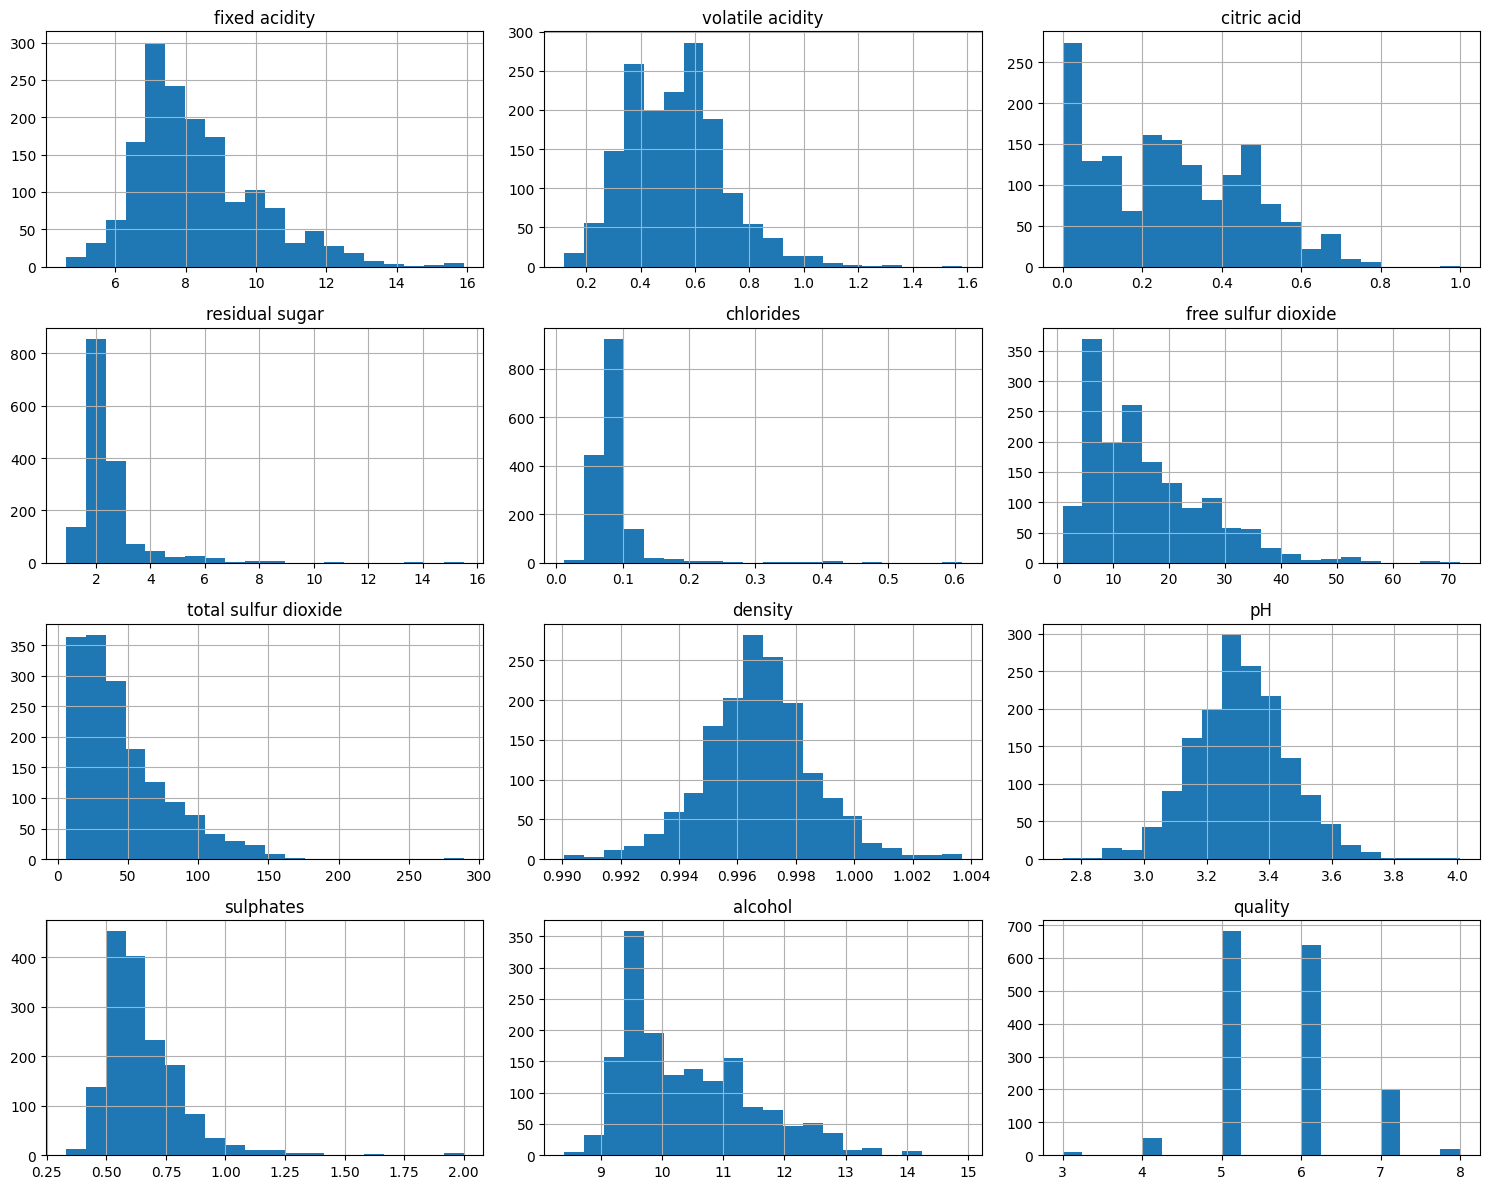

In [11]:
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

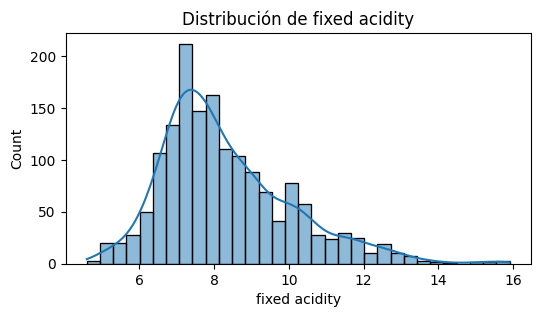

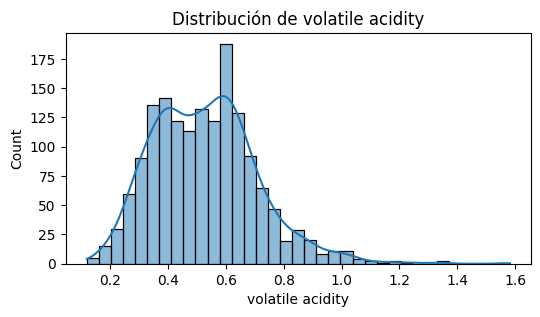

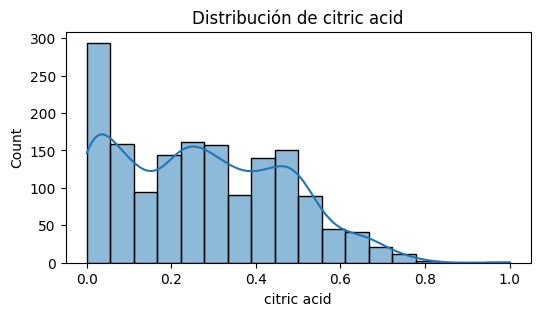

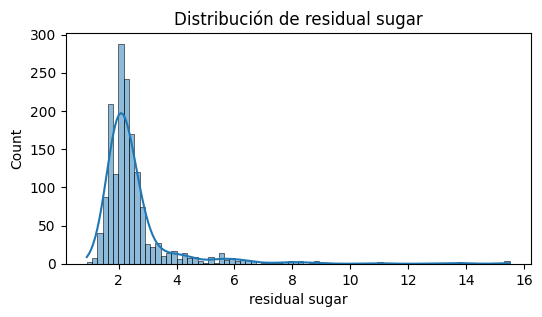

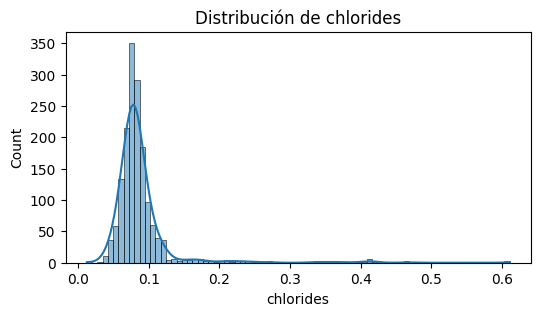

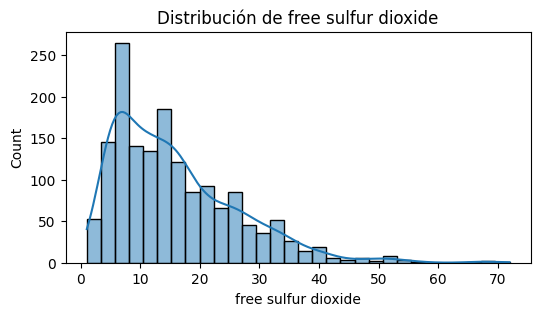

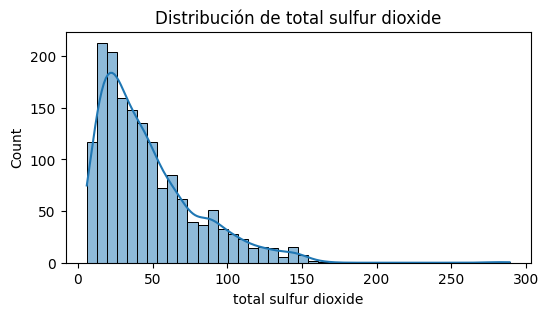

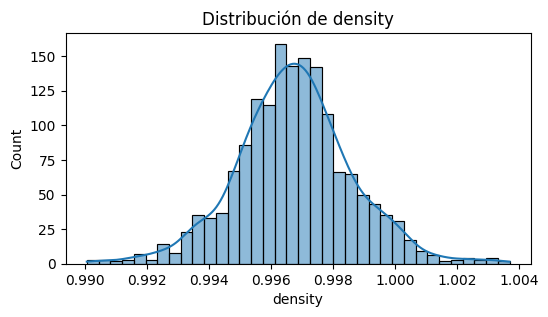

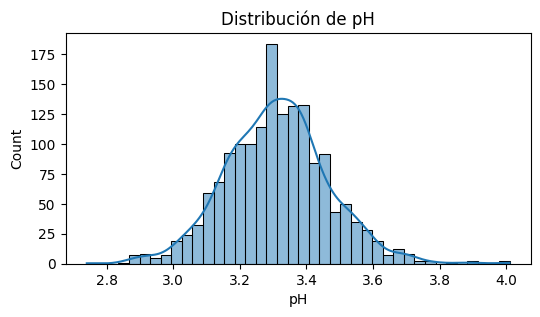

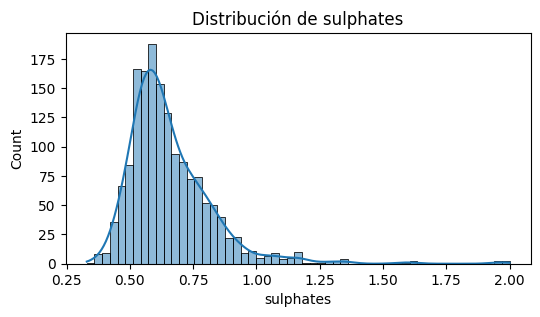

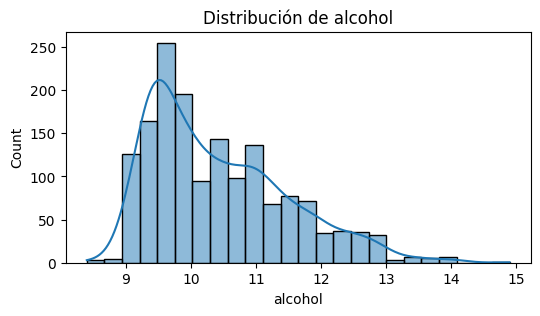

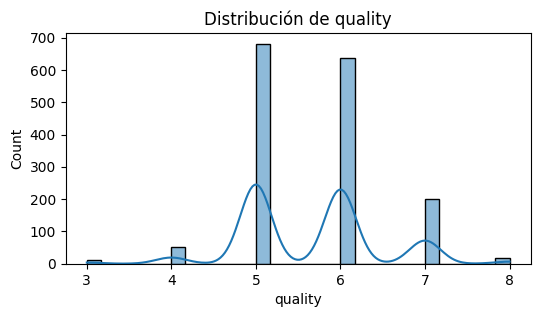

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.show()

Las variables químicas presentan diferentes escalas y distribuciones, algunas con sesgo y presencia de valores extremos, lo que justifica el uso de técnicas de normalización antes del entrenamiento del modelo.

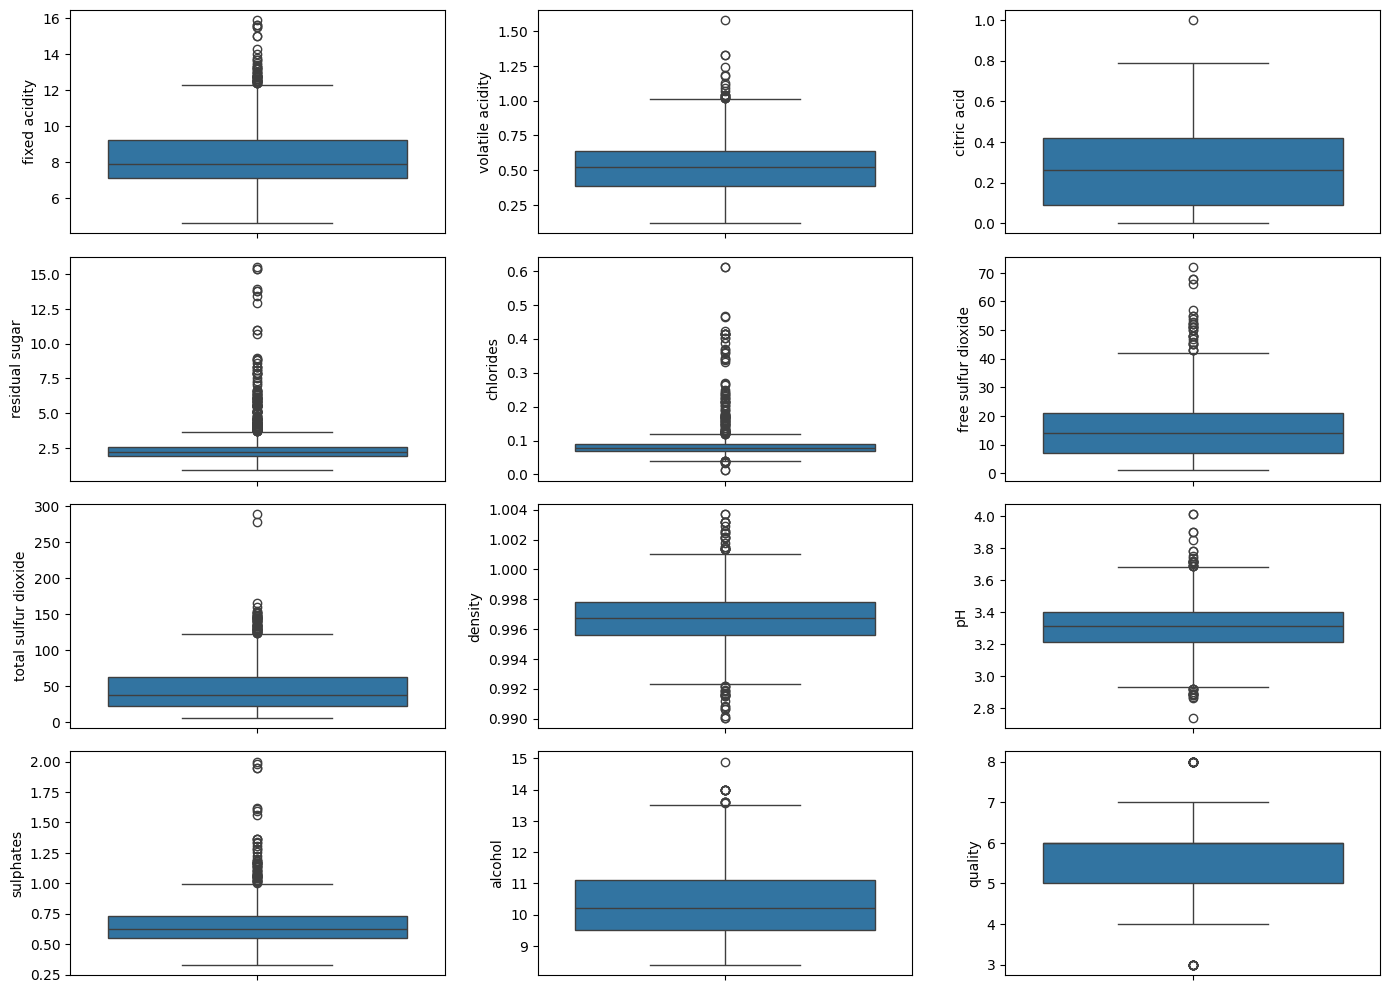

In [13]:
plt.figure(figsize=(14,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

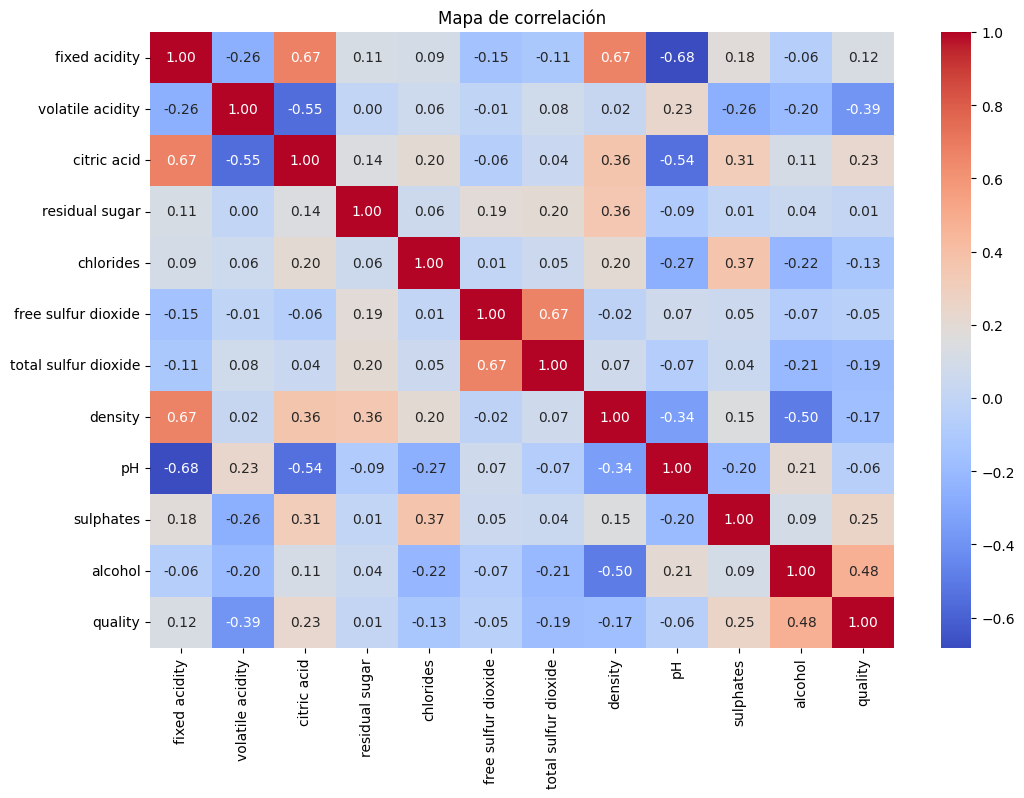

In [14]:
plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

El mapa de calor mostró correlaciones moderadas entre ciertas variables químicas, aunque no existen dependencias extremadamente altas que obliguen a eliminar características.

<a id="label"></a>
<div style="
background: linear-gradient(135deg, #f3e5f5, #e1f5fe);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#7E57C2;">
🏷️ Creación de Variable Objetivo (Label)
</h1>

<h3 style="color:#9575CD;">
Feature Engineering para Clasificación
</h3>

<p style="color:#666;">
🧠 Transformación de calidad numérica • 🎯 Clasificación multiclase • 📊 Análisis de balance de clases
</p>

</div>

In [15]:
df_model = df.copy()

In [16]:
df_model['label'] = pd.cut(df_model['quality'], bins=[0,5,6,10], labels=[0,1,2])

In [17]:
df_model['label'] = df_model['label'].astype(int)

In [18]:
df_model['label'].value_counts()

label
0    744
1    638
2    217
Name: count, dtype: int64

In [19]:
df_model = df_model.drop(columns="quality")

In [20]:
df_model.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'label'],
      dtype='str')

El dataset original presenta la variable quality como una escla numérica de evaluación del vino. Sin embargo. para adaptar el problema a un escenario de clasificación supervisada, se realizó una discretización agrupando los valores en tres categorías: baja, media y alta calidad. Esta transformación simplifica el problema y permite entrenar modelos de clasificación como KNN de manera más eficiente e interpretable

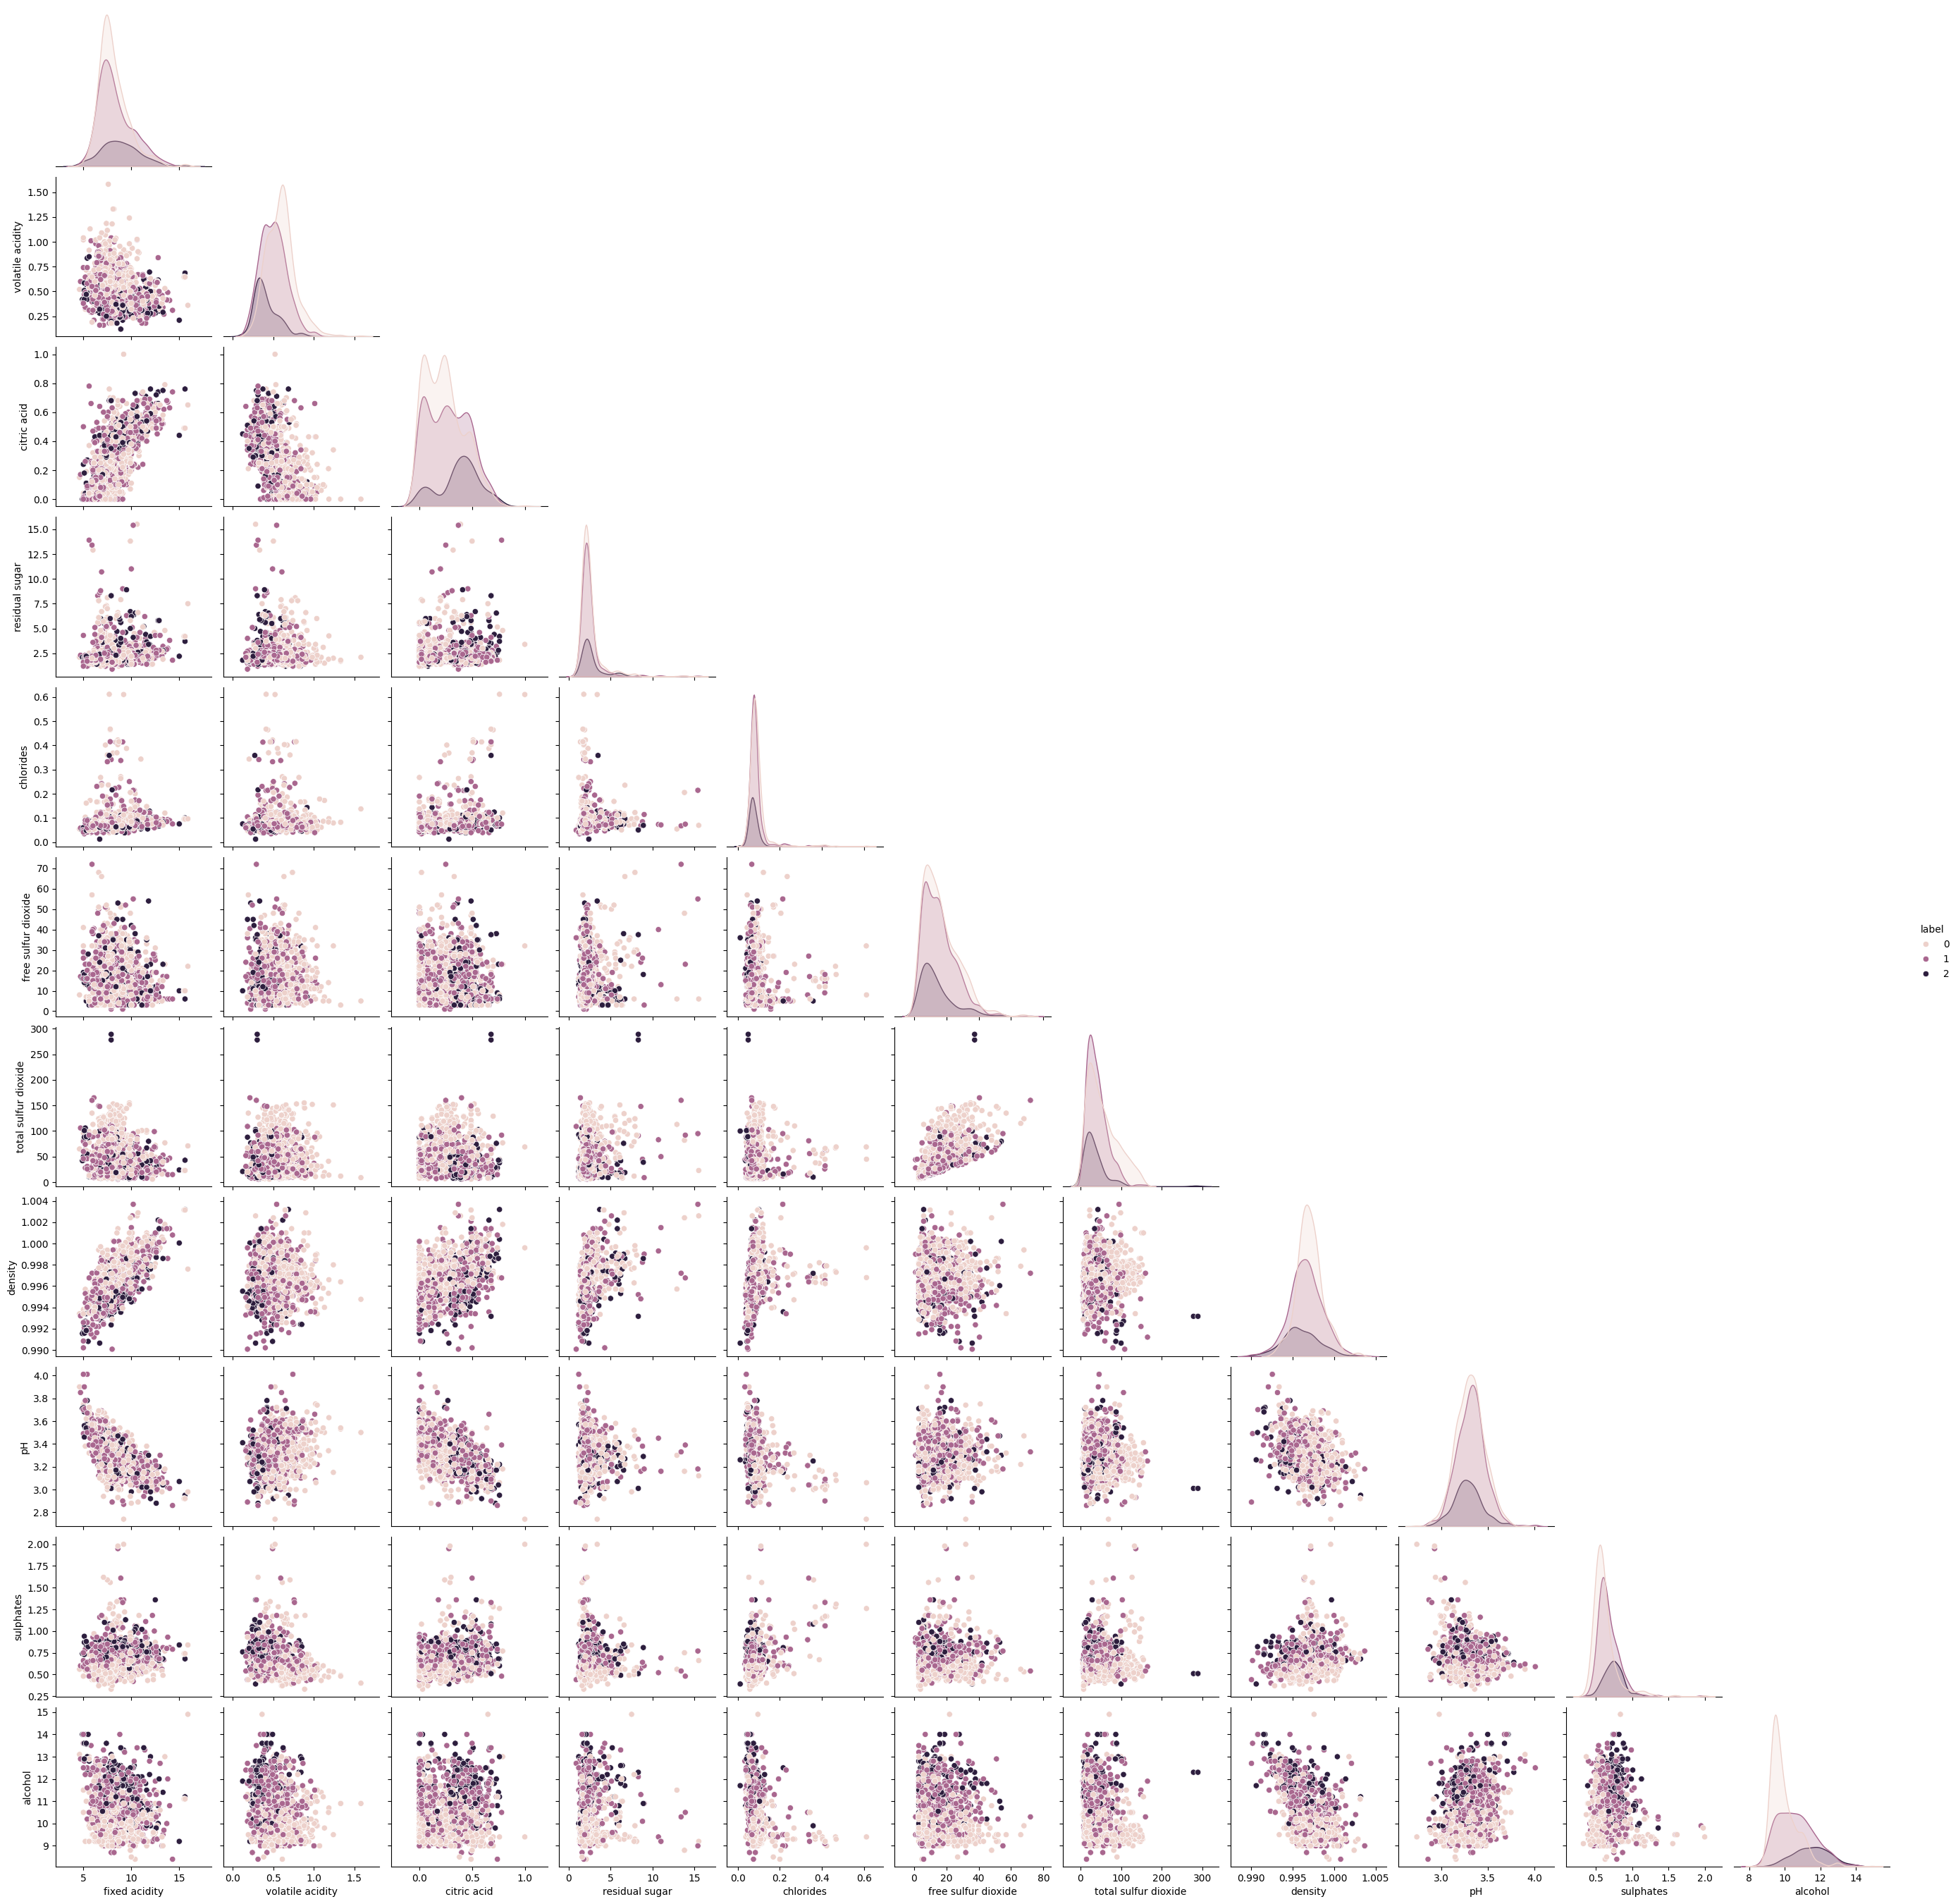

In [21]:
sns.pairplot(
    df_model,
    hue="label",
    corner=True,
    diag_kind="kde"
)
plt.show()

Los pairplots indican una separación parcial entre niveles de calidad, sugiriendo que un modelo basado en distancia como KNN puede capturar patrones relevantes.

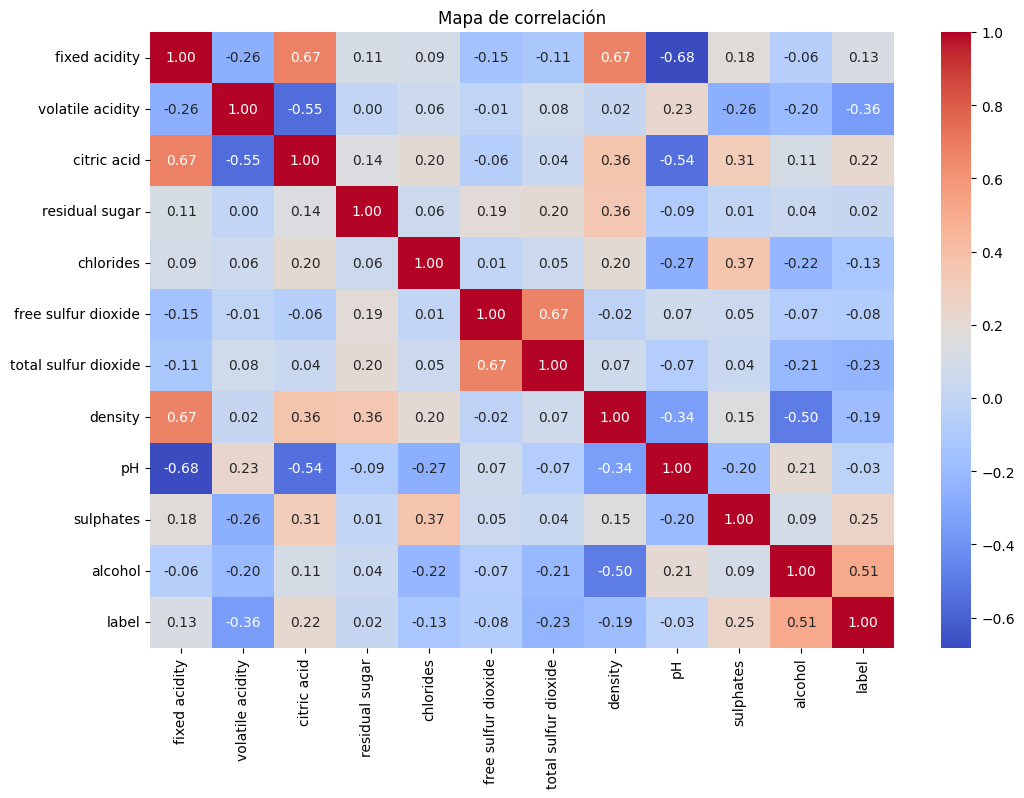

In [22]:
plt.figure(figsize=(12,8))

corr = df_model.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

El análisis exploratorio evidenció que:

El alcohol muestra relación positiva con la calidad.
La acidez volátil presenta relación negativa.
Los sulfatos contribuyen positivamente a vinos mejor evaluados.

Estas variables parecen ser fuertes indicadores de calidad.

In [23]:
corr["label"].sort_values(ascending=False)

label                   1.000000
alcohol                 0.507839
sulphates               0.252378
citric acid             0.217913
fixed acidity           0.126195
residual sugar          0.021784
pH                     -0.030279
free sulfur dioxide    -0.078917
chlorides              -0.125326
density                -0.186537
total sulfur dioxide   -0.232983
volatile acidity       -0.360621
Name: label, dtype: float64

### Alcohol vs Calidad

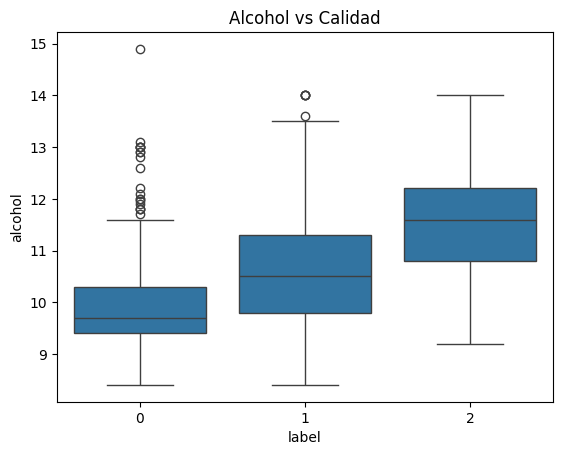

In [24]:
sns.boxplot(data=df_model, x="label", y="alcohol")
plt.title("Alcohol vs Calidad")
plt.show()

### Acidez Volátil vs Calidad

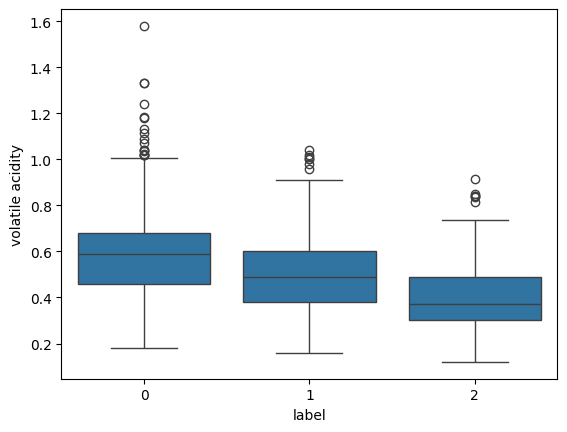

In [25]:
sns.boxplot(data=df_model, x="label", y="volatile acidity")
plt.show()

### Sulfatos vs Calidad

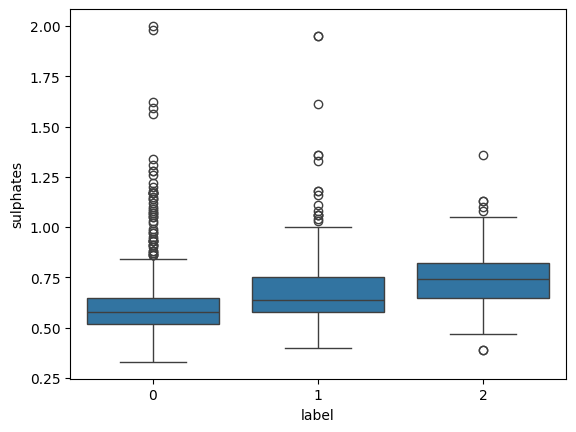

In [26]:
sns.boxplot(data=df_model, x="label", y="sulphates")
plt.show()

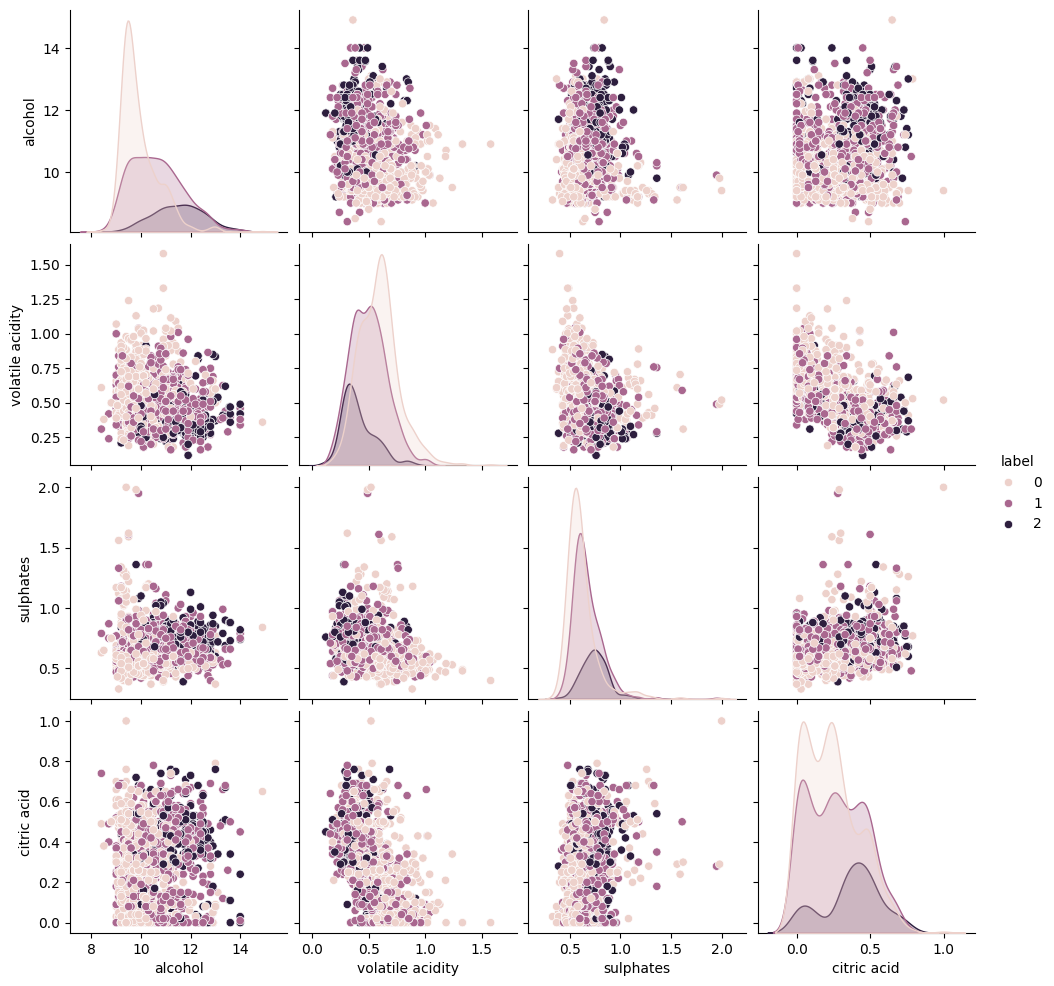

In [27]:
important_cols = ["alcohol", "volatile acidity", "sulphates", "citric acid", "label"]

sns.pairplot(df_model[important_cols], hue="label")
plt.show()

In [28]:
df_model["label"].value_counts(normalize=True)*100

label
0    46.529081
1    39.899937
2    13.570982
Name: proportion, dtype: float64

Las clases presentan ligera desproporción hacia vinos de calidad baja, lo cual debe considerarse durante la evaluación del modelo.

<a id="split"></a>
<div style="
background: linear-gradient(135deg, #e8f5e9, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#43A047;">
✂️ División de Datos y Preparación
</h1>

<h3 style="color:#66BB6A;">
Train/Test Split • Escalado • Preparación del Modelo
</h3>

<p style="color:#666;">
📊 Separación X e y • ⚙️ StandardScaler • 🧪 Datos listos para Machine Learning
</p>

</div>

In [29]:
X = df_model.drop("label", axis=1)
y = df_model["label"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<a id="training"></a>
<div style="
background: linear-gradient(135deg, #e3f2fd, #ede7f6);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#3949AB;">
🤖 Entrenamiento del Modelo KNN
</h1>

<h3 style="color:#7986CB;">
Aprendizaje Basado en Distancia
</h3>

<p style="color:#666;">
📍 Vecinos más cercanos • 🔎 Clasificación supervisada • ⚡ Modelo inicial k = 5
</p>

</div>

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)

In [33]:
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [34]:
y_pred = knn.predict(X_test_scaled)
y_pred

array([1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 1, 2, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       2, 0, 0, 1, 1, 2, 0, 1, 1, 2, 1, 1, 0, 1, 0, 0, 0, 2, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 2, 1, 0, 1, 2, 2, 1,
       0, 0, 0, 0, 1, 2, 0, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 1, 2,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 1, 0, 1, 1,
       0, 1, 0, 2, 0, 0, 0, 0, 1, 0, 2, 0, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 2, 0,
       0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 2, 0, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 2, 1, 0, 1, 0, 0,
       2, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2,
       0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 1, 1, 2, 1, 1,

<a id="evaluation"></a>
<div style="
background: linear-gradient(135deg, #fff3e0, #fce4ec);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#FB8C00;">
📊 Evaluación del Modelo
</h1>

<h3 style="color:#F06292;">
Medición del Rendimiento Predictivo
</h3>

<p style="color:#666;">
✅ Accuracy • 🔲 Confusion Matrix • 📄 Classification Report
</p>

</div>

In [35]:
accuracy_score(y_test, y_pred)

0.625

In [36]:
confusion_matrix(y_test, y_pred)

array([[103,  46,   0],
       [ 38,  77,  13],
       [  7,  16,  20]])

In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.69      0.69       149
           1       0.55      0.60      0.58       128
           2       0.61      0.47      0.53        43

    accuracy                           0.62       320
   macro avg       0.62      0.59      0.60       320
weighted avg       0.63      0.62      0.62       320



<a id="optimization"></a>
<div style="
background: linear-gradient(135deg, #e0f7fa, #ede7f6);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#00838F;">
⚙️ Optimización del Hiperparámetro K
</h1>

<h3 style="color:#7E57C2;">
Búsqueda del Mejor Número de Vecinos
</h3>

<p style="color:#666;">
📈 Accuracy vs K • 🔎 Validación experimental • 🎯 Selección del modelo óptimo
</p>

</div>

In [38]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

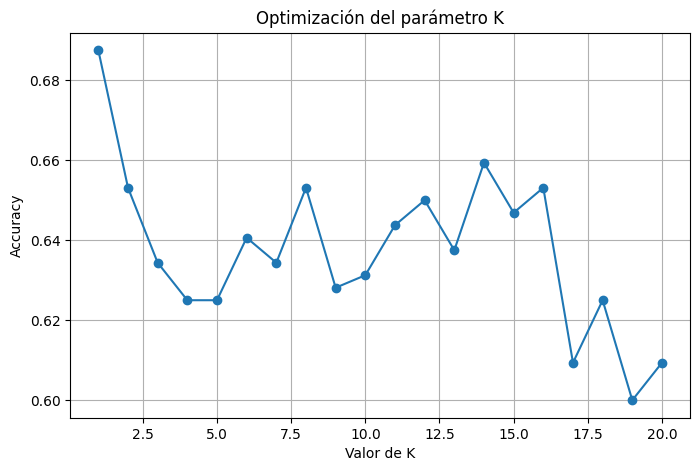

In [39]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Valor de K")
plt.ylabel("Accuracy")
plt.title("Optimización del parámetro K")
plt.grid()

plt.show()

In [40]:
best_k = k_values[np.argmax(accuracies)]
best_k

1

El modelo funciona mejor con el vecino más cercano lo que quiere decir que los vinos más parecidos químicamente suelen tener la misma calidad.
Por otro lado esto podría indicar un posible overfitting ya que el modelo memoriza ejemplos individuales, es muy sensible al ruido y puede fallar con nuevos datos

<a id="bestk"></a>
<div style="
background: linear-gradient(135deg, #e8f5e9, #f1f8e9);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#2E7D32;">
🏆 Modelo Óptimo — Best K
</h1>

<h3 style="color:#66BB6A;">
Máximo Accuracy Obtenido
</h3>

<p style="color:#666;">
🚀 k = 1 • Mejor rendimiento predictivo • Modelo model_bestk
</p>

</div>

In [41]:
model_bestK = KNeighborsClassifier(n_neighbors=best_k)
model_bestK.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
orden = np.argsort(accuracies)[::-1]
print(k_values[orden[1]])

14


<a id="stablek"></a>
<div style="
background: linear-gradient(135deg, #ede7f6, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#5E35B1;">
🛡️ Modelo Estable — Stable K
</h1>

<h3 style="color:#7986CB;">
Mayor Capacidad de Generalización
</h3>

<p style="color:#666;">
⚖️ k = 14 • Menor sobreajuste • Modelo model_stablek
</p>

</div>

In [43]:
model_stabel = KNeighborsClassifier(n_neighbors=14)
model_stabel.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


La optimización del parámetro k evidenció que el mayor valor de accuracy se obtiene con k=1. sin embargo, este valor puede generar sobreajuste al basarse únicamente en el vecino más cercano. Se observa que valores entre 13 y 15 presentan un rendimiento similar pero más estable, por lo que presentan una mejor capacidad de generalización del modelo KNN.

<a id="prediction"></a>
<div style="
background: linear-gradient(135deg, #fce4ec, #f3e5f5);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#C2185B;">
🍷 Predicción de Calidad del Vino
</h1>

<h3 style="color:#8E24AA;">
Aplicación del Modelo Entrenado
</h3>

<p style="color:#666;">
🤖 Predicción automática • 🔬 Análisis químico • 🍇 Evaluación estilo sommelier IA
</p>

</div>

In [46]:
def predict_wine_quality(values):

    values = np.array(values).reshape(1, -1)
    
    values_scaled = scaler.transform(values)
    
    prediction = model_bestK.predict(values_scaled)[0]
    
    if prediction == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    
    elif prediction == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    
    else:
        return "Este vino probablemente sea de alta calidad 🍷"

In [47]:
predict_wine_quality(
    [7.4, 0.7, 0.0, 1.9, 0.076,
     11.0, 34.0, 0.9978, 3.51,
     0.56, 9.4]
)

c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Este vino probablemente sea de baja calidad 🍷'

<a id="conclusion"></a>
<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1800px;
margin:auto;
color:#000000;
">

<h2 style="text-align:center; color:#7E57C2;">
🍷 Conclusión Final — Clasificador de Calidad de Vinos con KNN
</h2>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El desarrollo de este proyecto permitió construir un sistema de clasificación automática de la calidad del vino tinto mediante técnicas de 
<strong style="color:#6C9BCF;">Machine Learning Supervisado</strong> utilizando el algoritmo 
<strong style="color:#26A69A;">K-Nearest Neighbors (KNN)</strong>.
Durante la fase inicial se realizó un 
<span style="background-color:#F3E5F5; padding:4px 8px; border-radius:8px;">
Análisis Exploratorio de Datos (EDA)
</span>
completo, evaluando la estructura del dataset, distribuciones estadísticas, detección de valores atípicos y relaciones entre variables químicas mediante histogramas, boxplots, pairplots y mapas de correlación.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El conjunto de datos original no contenía una variable categórica para clasificación, por lo que fue necesario crear la columna 
<span style="background-color:#EDE7F6; padding:4px 8px; border-radius:8px;">
label
</span>
a partir de los niveles de calidad del vino, transformando el problema en una tarea de 
<strong style="color:#5C6BC0;">clasificación multiclase</strong>:
baja, media y alta calidad. Esta etapa constituyó un proceso de 
<strong style="color:#7E57C2;">feature engineering</strong>, fundamental para permitir el entrenamiento del modelo supervisado.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El análisis exploratorio evidenció que variables como el 
<strong style="color:#26A69A;">alcohol</strong>, los 
<strong style="color:#6C9BCF;">sulfatos</strong> y la 
<strong style="color:#FF8A65;">acidez volátil</strong>
presentan influencia directa sobre la calidad del vino. Asimismo, se identificaron diferencias importantes de escala entre las variables, razón por la cual se aplicó 
<span style="background-color:#E3F2FD; padding:4px 8px; border-radius:8px;">
StandardScaler
</span>
siguiendo buenas prácticas para algoritmos basados en distancia.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El modelo inicial fue entrenado utilizando 
<strong style="color:#7E57C2;">KNeighborsClassifier (k = 5)</strong>,
siendo evaluado mediante 
<strong style="color:#26A69A;">accuracy</strong>, 
<strong style="color:#5C6BC0;">confusion matrix</strong> y 
<strong style="color:#6C9BCF;">classification report</strong>,
lo que permitió analizar tanto el rendimiento global como la capacidad de clasificación por cada categoría de calidad.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Posteriormente se realizó la optimización del hiperparámetro 
<span style="background-color:#E8F5E9; padding:4px 8px; border-radius:8px;">
n_neighbors (k)
</span>,
evaluando múltiples configuraciones. El mejor resultado en términos de accuracy se obtuvo con 
<strong style="color:#26A69A;">k = 1</strong>, definiéndose como el modelo 
<strong>model_bestk</strong>. No obstante, valores extremadamente bajos pueden generar 
<strong style="color:#FF7043;">sobreajuste</strong>, al depender excesivamente de observaciones individuales.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Por esta razón, también se entrenó un segundo modelo con 
<strong style="color:#7E57C2;">k = 14</strong>, denominado 
<strong>model_stablek</strong>, el cual presentó un rendimiento muy cercano al óptimo pero con mayor estabilidad y mejor capacidad de generalización. Este enfoque permitió contrastar dos principios fundamentales del Machine Learning:
</p>

<ul style="font-size:16px; line-height:1.7;">
<li>✅ <strong>Modelo óptimo:</strong> maximiza la exactitud inmediata.</li>
<li>✅ <strong>Modelo estable:</strong> prioriza robustez y desempeño ante nuevos datos.</li>
</ul>

<p style="font-size:16px; line-height:1.7; color:#000000;">
En conclusión, el algoritmo KNN demostró ser una herramienta eficaz para clasificar la calidad del vino a partir de propiedades químicas, evidenciando cómo la inteligencia artificial puede apoyar procesos de evaluación similares a los realizados por expertos sommeliers. El proyecto integra correctamente todas las etapas del flujo de ciencia de datos —EDA, ingeniería de variables, preparación del dataset, entrenamiento, evaluación y optimización— destacando la importancia de equilibrar rendimiento predictivo y estabilidad del modelo para lograr soluciones confiables en escenarios reales.
</p>

</div>
